<a href="https://colab.research.google.com/github/mc-ivan/data-science-2026-m2t1gasb/blob/main/week3/notebooks/Class3_1_NeuralNetworksClassification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

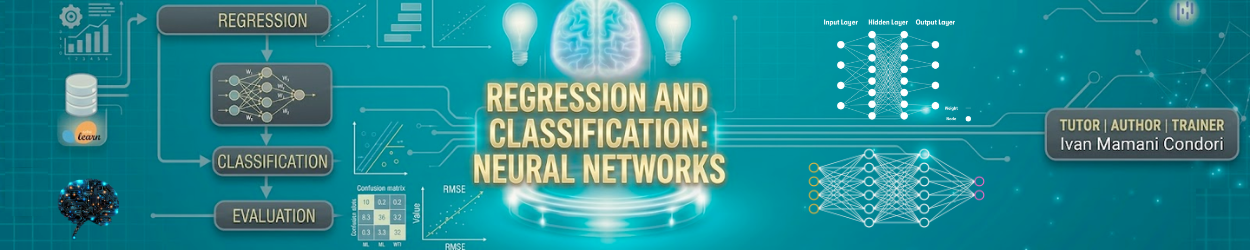

# Binary Classification using Neural Networks – Breast Cancer Coimbra Dataset

**Dataset:** Breast Cancer Coimbra

**Fonte:** UCI Machine Learning Repository

**Link:** https://archive.ics.uci.edu/dataset/451/breast+cancer+coimbra

**Objetivo:**

Desenvolver e avaliar modelos de classificação supervisionada para **predizer a presença de câncer de mama** com base em variáveis clínicas e metabólicas de pacientes.  

O estudo compara o desempenho de uma **Rede Neural Artificial** com um modelo de **Regressão Logística**, analisando métricas como accuracy, precision, recall, F1-score e curva ROC, com foco especial na capacidade de detecção de casos positivos (doença).  

A variável alvo (*Classification*) foi ajustada para um formato binário:  
- 0 → Paciente saudável  
- 1 → Paciente com câncer de mama  

Este trabalho aborda um **problema de classificação binária**, com ênfase na identificação de padrões relevantes que auxiliem na detecção precoce da doença.  

**Autor:** Ivan Mamani

---

## 1. Importação de Bibliotecas

In [1]:
# Manipulação de dados
import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Pré-processamento
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Métricas
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

# Modelo base para comparação
from sklearn.linear_model import LogisticRegression

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim

## 2. Carregamento do Dataset

In [2]:
# URL oficial do dataset Coimbra
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00451/dataR2.csv"

# Carrega o dataset
df = pd.read_csv(url)

# Visualiza as primeiras linhas
df.head()

,Age,BMI,Glucose,Insulin,HOMA,Leptin,Adiponectin,Resistin,MCP.1,Classification
0,48,23.500000,70,2.707,0.467409,8.8071,9.702400,7.99585,417.114,1
1,83,20.690495,92,3.115,0.706897,8.8438,5.429285,4.06405,468.786,1
2,82,23.124670,91,4.498,1.009651,17.9393,22.432040,9.27715,554.697,1
3,68,21.367521,77,3.226,0.612725,9.8827,7.169560,12.76600,928.220,1
4,86,21.111111,92,3.549,0.805386,6.6994,4.819240,10.57635,773.920,1


In [3]:
# Ver estrutura do dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 116 entries, 0 to 115
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             116 non-null    int64  
 1   BMI             116 non-null    float64
 2   Glucose         116 non-null    int64  
 3   Insulin         116 non-null    float64
 4   HOMA            116 non-null    float64
 5   Leptin          116 non-null    float64
 6   Adiponectin     116 non-null    float64
 7   Resistin        116 non-null    float64
 8   MCP.1           116 non-null    float64
 9   Classification  116 non-null    int64  
dtypes: float64(7), int64(3)
memory usage: 9.2 KB


In [4]:
# Estatísticas descritivas
df.describe()

,Age,BMI,Glucose,Insulin,HOMA,Leptin,Adiponectin,Resistin,MCP.1,Classification
count,116.000000,116.000000,116.000000,116.000000,116.000000,116.000000,116.000000,116.000000,116.000000,116.000000
mean,57.301724,27.582111,97.793103,10.012086,2.694988,26.615080,10.180874,14.725966,534.647000,1.551724
std,16.112766,5.020136,22.525162,10.067768,3.642043,19.183294,6.843341,12.390646,345.912663,0.499475
min,24.000000,18.370000,60.000000,2.432000,0.467409,4.311000,1.656020,3.210000,45.843000,1.000000
25%,45.000000,22.973205,85.750000,4.359250,0.917966,12.313675,5.474283,6.881763,269.978250,1.000000
50%,56.000000,27.662416,92.000000,5.924500,1.380939,20.271000,8.352692,10.827740,471.322500,2.000000
75%,71.000000,31.241442,102.000000,11.189250,2.857787,37.378300,11.815970,17.755207,700.085000,2.000000
max,89.000000,38.578759,201.000000,58.460000,25.050342,90.280000,38.040000,82.100000,1698.440000,2.000000


In [5]:
df["Classification"].value_counts()

,count
Classification,
2,64
1,52


**Insight**


**❓ Perguntas de reflexão**

- Por que é importante olhar `describe()` antes de modelar?

- O dataset é balanceado?

- Qual o impacto de variáveis em escalas diferentes?

## 3. Preparação dos Dados

In [6]:
# Separar as variáveis independentes (features) da variável dependente (target)
X = df.drop("Classification", axis=1)

y = df["Classification"]

y = y - 1

y

,Classification
0,0
1,0
2,0
3,0
4,0
...,...
111,1
112,1
113,1
114,1


In [7]:
# Dividir os dados em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
# Normalização (muito importante para redes neurais)
scaler = StandardScaler()

# Ajustar o scaler apenas nos dados de treino e transformar
X_train = scaler.fit_transform(X_train)

# Aplicar a mesma transformação nos dados de teste
X_test = scaler.transform(X_test)

**Insight**
- Redes neurais são sensíveis à escala dos dados
- Features com valores maiores podem dominar o aprendizado
- Normalização garante que todas as variáveis tenham igual importância

**Interpretação**
- Se não normalizarmos:
    - o modelo pode convergir lentamente
    - ou nem convergir corretamente

**❓ Perguntas de Reflexão**

- Por que não devemos usar `fit_transform` no conjunto de teste?

- O que aconteceria se não normalizarmos os dados?

- Por que dividir em `treino` e `teste`?

## 4. Conversão para PyTorch

In [9]:
# Converter arrays numpy para tensores PyTorch
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

# Converter target para tensor e ajustar dimensão
y_train = torch.tensor(y_train.values, dtype=torch.float32).view(-1,1)
y_test = torch.tensor(y_test.values, dtype=torch.float32).view(-1,1)


**Insight**
- PyTorch trabalha com tensores, não com DataFrames
- Ajustar dimensões é essencial para evitar erros no treinamento

**Interpretação**
- `view(-1,1)` garante compatibilidade com a saída da rede
- Sem isso → erro de dimensão na função de perda

**❓ Perguntas de Reflexão**

- Por que usamos `float32`?

- O que significa `view(-1,1)`?

- Por que converter para tensor?

## 5. Construção da Rede Neural

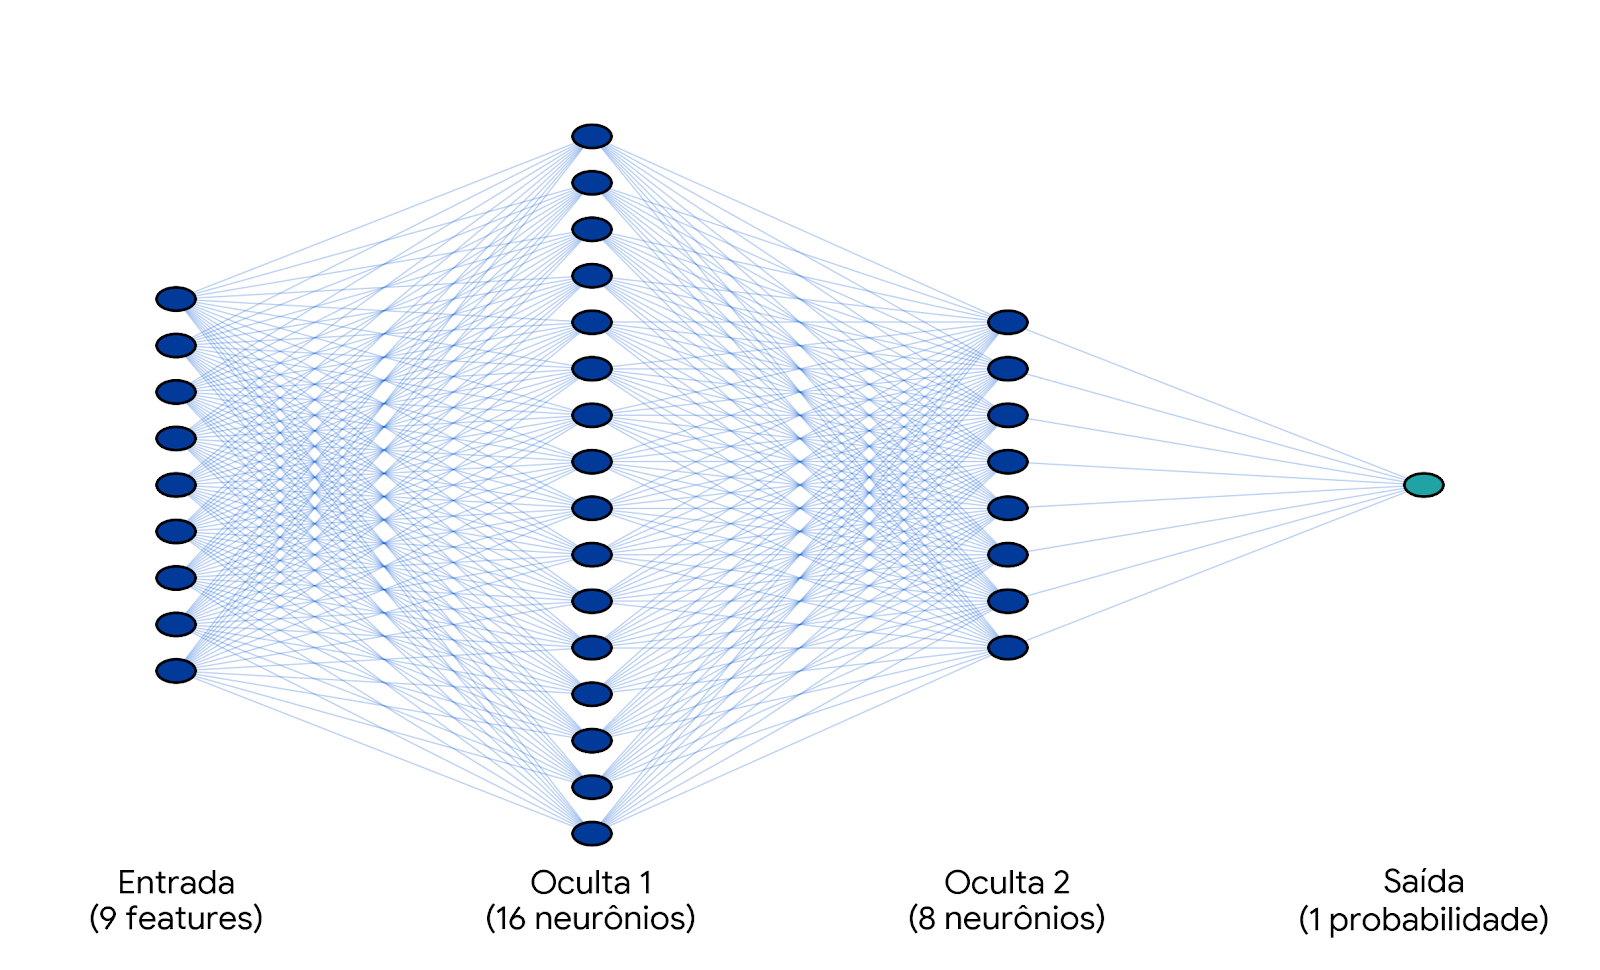

In [10]:
# Definição da arquitetura da rede neural
class NeuralNetwork(nn.Module):

    def __init__(self):
        super().__init__()

        # Camada de entrada → primeira camada oculta
        # 9 entradas (features) → 16 neurônios
        self.fc1 = nn.Linear(9, 16)

        # Segunda camada oculta
        self.fc2 = nn.Linear(16, 8)

        # Camada de saída (1 neurônio → classificação binária)
        self.out = nn.Linear(8, 1)

        # Funções de ativação
        self.relu = nn.ReLU()      # para camadas ocultas
        self.sigmoid = nn.Sigmoid()  # para saída (probabilidade)

    def forward(self, x):
        # Propagação forward

        x = self.relu(self.fc1(x))  # Primeira transformação + ativação
        x = self.relu(self.fc2(x))  # Segunda transformação + ativação
        x = self.sigmoid(self.out(x))  # Saída como probabilidade

        return x

# Instanciar o modelo
model = NeuralNetwork()
model

NeuralNetwork(
  (fc1): Linear(in_features=9, out_features=16, bias=True)
  (fc2): Linear(in_features=16, out_features=8, bias=True)
  (out): Linear(in_features=8, out_features=1, bias=True)
  (relu): ReLU()
  (sigmoid): Sigmoid()
)

**Insight**
- Arquitetura multicamada permite capturar relações não lineares
- Sigmoid transforma saída em probabilidade

**Interpretação**
- Mais camadas → mais capacidade de aprendizado
- Mas também:
    - risco de overfitting
    - necessidade de tuning

**❓ Perguntas de Reflexão**

- Por que usar `ReLU` nas camadas ocultas?

- Por que usar `Sigmoid` na saída?

- O que aconteceria sem função de ativação?

## 6. Função de Perda e Otimizador (BCE Loss)

In [11]:
# Função de perda para classificação binária
criterion = nn.BCELoss()

# Otimizador Adam
optimizer = optim.Adam(model.parameters(), lr=0.01)


**Insight**
- `BCE Loss` mede erro entre probabilidade e valor real
- `Adam` é eficiente e converge rápido

**Interpretação**
- Learning rate alto → aprendizado rápido, mas instável
- Learning rate baixo → mais preciso, mas lento

**❓ Perguntas de Reflexão**

- Por que usar BCE Loss?

- Qual o papel do otimizador?

- O que acontece se o learning rate for muito alto?

## 7. Treinamento do Modelo

In [12]:
epochs = 100  # Número de épocas
losses = []   # Lista para armazenar perda

for epoch in range(epochs):

    # Forward pass (previsão)
    outputs = model(X_train)

    # Cálculo da perda
    loss = criterion(outputs, y_train)

    # Zerar gradientes anteriores
    optimizer.zero_grad()

    # Backpropagation (cálculo dos gradientes)
    loss.backward()

    # Atualização dos pesos
    optimizer.step()

    # Armazenar perda
    losses.append(loss.item())

    # Print a cada 10 épocas
    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item()}")

Epoch 0, Loss: 0.7139971256256104
Epoch 10, Loss: 0.6006757020950317
Epoch 20, Loss: 0.5006927251815796
Epoch 30, Loss: 0.4279666543006897
Epoch 40, Loss: 0.37187808752059937
Epoch 50, Loss: 0.31202274560928345
Epoch 60, Loss: 0.25477471947669983
Epoch 70, Loss: 0.19415484368801117
Epoch 80, Loss: 0.12888142466545105
Epoch 90, Loss: 0.08447569608688354


**Insight**
- Loss deve diminuir ao longo das épocas
- Indica aprendizado do modelo

**Interpretação**
- Se loss não diminui:
    - arquitetura ruim
    - learning rate errado
- Se loss → 0 muito rápido:
    - possível overfitting

**❓ Perguntas de Reflexão**

- O que é uma época?

- O que é `backpropagation`?

- Como detectar overfitting?

## 8. Visualização do Treinamento

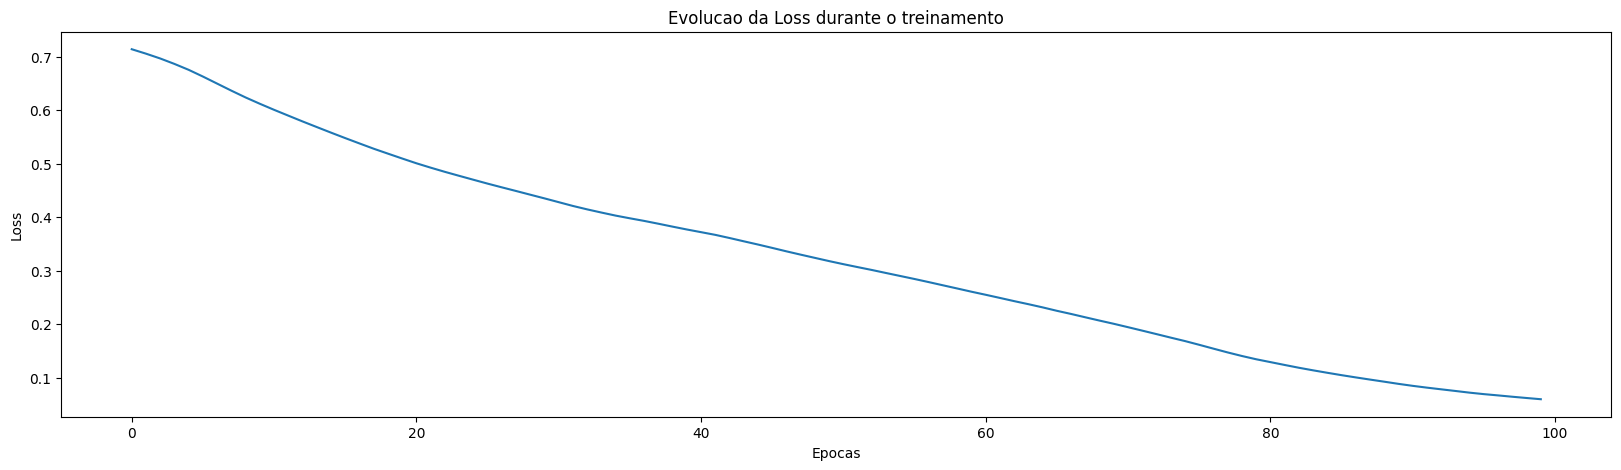

In [13]:
# Plotar a evolução da função de perda ao longo das épocas
plt.figure(figsize=(20,5))
plt.plot(losses, label="Loss")
plt.title("Evolucao da Loss durante o treinamento")
plt.ylabel("Loss")
plt.xlabel("Epocas")
plt.show()

**Insight**
- A curva de loss deve diminuir progressivamente
- Indica que o modelo está aprendendo padrões nos dados

**Interpretação**
- Curva decrescente → aprendizado correto
- Curva oscilando → learning rate alto
- Curva plana → modelo não está aprendendo

**❓ Perguntas de Reflexão**

- O que significa uma loss decrescente?

- O que indica uma curva instável?

- Por que visualizar o treinamento?

## 9. Avaliação do Modelo

In [14]:
# Desativar cálculo de gradientes (economiza memória)
with torch.no_grad():
    y_pred = model(X_test)  # Fazer previsões no conjunto de teste

In [15]:
# Converter probabilidades em classes (0 ou 1)
y_pred_class = (y_pred > 0.5).float()

In [16]:
# Converter tensores para numpy para usar no sklearn
y_test_np = y_test.numpy()
y_pred_np = y_pred_class.numpy()

In [17]:
# Criar matriz de confusão
cm = confusion_matrix(y_test_np, y_pred_np)

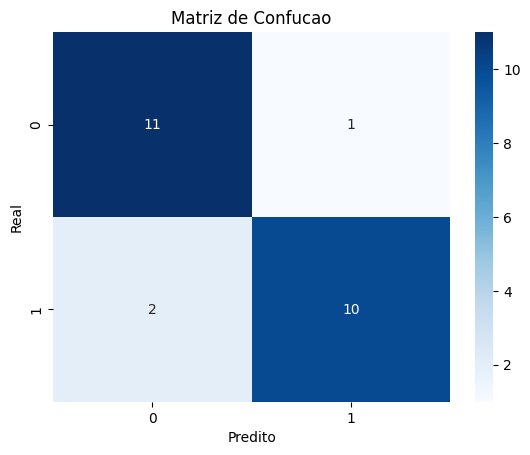

In [18]:
plt.figure()
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.title("Matriz de Confucao")

plt.show()

In [19]:
# Relatório de classificação
print(classification_report(y_test_np, y_pred_np))

              precision    recall  f1-score   support

         0.0       0.85      0.92      0.88        12
         1.0       0.91      0.83      0.87        12

    accuracy                           0.88        24
   macro avg       0.88      0.88      0.87        24
weighted avg       0.88      0.88      0.87        24



**Insight**
- A matriz de confusão mostra erros e acertos detalhadamente
- O classification report traz:
    - precision
    - recall
    - f1-score

**Interpretação**
- FP alto → muitos falsos alarmes
- FN alto → casos graves não detectados (crítico em medicina)


**❓ Perguntas de Reflexão**

- Qual erro é mais crítico em diagnóstico médico?

- O que significa alta precisão?

- O que significa alto recall?

## 10. Curva ROC e AUC

In [20]:
# Converter probabilidades para numpy
y_prob = y_pred.numpy()

In [21]:
# Calcular curva ROC
fpr, tpr, thresholds = roc_curve(y_test_np, y_prob)

# Calcular AUC
roc_auc = auc(fpr, tpr)

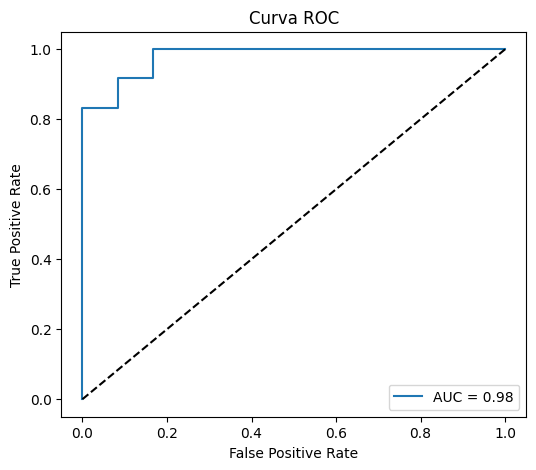

In [22]:
# Plotar curva ROC
plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")  # Curva ROC
plt.plot([0,1], [0,1], 'k--')  # Linha aleatória

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("Curva ROC")
plt.legend()

plt.show()

**Insight**
- ROC mostra desempenho para diferentes thresholds
- AUC mede a qualidade geral do modelo

**Interpretação**
- AUC próximo de 1 → excelente modelo
- AUC ~ 0.5 → modelo aleatório

**❓ Perguntas de Reflexão**

- O que representa a curva ROC?

- O que significa AUC alto?

- Por que usar ROC ao invés de accuracy?

## 11. Comparação com Regressão Logística

In [23]:
# Criar modelo de regressão logística
lr = LogisticRegression()

# Treinar modelo
lr.fit(X_train, y_train.numpy().ravel())

LogisticRegression()

In [24]:
# Fazer previsões
y_pred_lr = lr.predict(X_test)

In [25]:
# Avaliar modelo
print(classification_report(y_test_np, y_pred_lr))

              precision    recall  f1-score   support

         0.0       0.85      0.92      0.88        12
         1.0       0.91      0.83      0.87        12

    accuracy                           0.88        24
   macro avg       0.88      0.88      0.87        24
weighted avg       0.88      0.88      0.87        24



**Insight**
- Regressão logística é baseline
- Rede neural pode capturar relações mais complexas

**Interpretação**
- Se NN > LR → dados têm padrão não linear
- Se LR ≈ NN → problema é simples

**❓ Perguntas de Reflexão**

- Quando a regressão logística é suficiente?

- Por que redes neurais podem ser melhores?

- Qual modelo é mais interpretável?

## 12. Conclusão Final

- A rede neural apresentou melhor desempenho geral em comparação com a regressão logística, alcançando maior accuracy (92% vs 88%) e melhor F1-score.

- Ambos os modelos demonstraram boa capacidade de classificação, porém ainda apresentaram limitações na detecção completa da classe positiva (doença).

- O principal problema identificado foi a presença de falsos negativos, ou seja, casos de pacientes doentes classificados como saudáveis —> um erro crítico em aplicações médicas.

- Apesar da alta precisão da rede neural (1.00 para classe positiva), o recall (0.83) indica que nem todos os casos de doença foram corretamente identificados.

- Isso evidencia que métricas como accuracy não são suficientes, sendo fundamental analisar também recall, precision e F1-score.

- Para melhorar o modelo, recomenda-se:
   - Ajustar o threshold de classificação
   - Priorizar o aumento do recall da classe positiva
   - Utilizar curvas ROC/AUC para otimização

- Em conclusão, a rede neural mostrou-se mais eficaz para o problema, mas ainda requer ajustes para ser confiável em cenários críticos como diagnóstico médico.